In [69]:
import numpy as np
import matplotlib.pyplot as plt
x, w = np.polynomial.laguerre.laggauss(50)
xj, wj = np.polynomial.legendre.leggauss(50)
import ODESolve_slow as ODE
import derivatives as der

In [71]:
dm=1.293
gA=1.27
GF=1.166e-11
me=0.511


In [73]:
#antineutrino distribution function
def fanti(E,Tcm):
    fanti=(np.exp(E/Tcm)+1)**(-1)
    return fanti

In [75]:
#electron distribution fucntion
def fe(E,T):
    fe=(np.exp(E/T)+1)**(-1)
    return fe

In [77]:
#neutrino distributuon fucntion
def fneutrino(E,Tcm):
    fneutrino=(np.exp(E/Tcm)+1)**(-1)
    return fneutrino

In [79]:
#positron distribution fucntion
def fpos(E,T):
    fpos=(np.exp(E/T)+1)**(-1)
    return fpos

In [81]:
#integrand for neutrond ecay rate
def g(x,T,Tcm):
    delta=dm/Tcm
    u=me/Tcm
    g=(x**2)*(delta-x)*np.sqrt((delta-x)**2-u**2)*(1-fanti(x*Tcm,Tcm))*(1-fe((delta-x)*Tcm,T))
    return g

In [83]:
#Neutron Decay Rate


def N(T,a):
    Tcm=1/a
    delta=dm/Tcm
    u=me/Tcm
    integrand=np.zeros(50)
    A=delta-u
  
    for j in range(len(integrand)):
        E=(A/2)*(xj[j]+1)
        integrand[j] = g(E,T,Tcm)
    return ((GF**2)/(2*np.pi**3))*(1+(3*(gA**2)))*(Tcm**5)*(A/2)*np.sum(wj*integrand)  


In [85]:
#solve ODE
a0=0.1    
y0=np.array([10,0])
dx0=0.001
p=None

N_step = 1000
dN = 2
x_final = 100
a, y, dx, done = ODE.ODEOneRun(a0, y0, dx0, p, N_step, dN, x_final)
print(done)

True


Text(0, 0.5, 'rate (s^-1)')

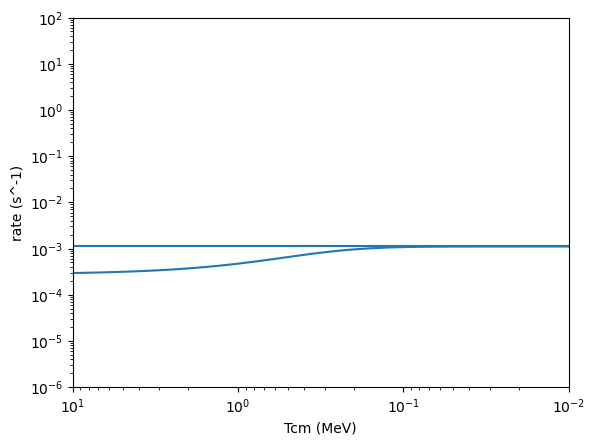

In [86]:
#Figure 2

plt.figure()
T = y[:,0]
z = np.zeros(len(T))
for i in range(len(T)):
    z[i] = N(T[i],a[i])/(6.58e-22)
plt.loglog(1/a,z)
plt.xlim(1e1,1e-2)
plt.ylim(1e-6,1e2)
plt.axhline(1/903)
plt.xlabel("Tcm (MeV)")
plt.ylabel("rate (s^-1)")



In [87]:
#integrand for rate antineutrino,electron,proton

def g_antiep(x,T,Tcm):
    delta=dm/Tcm
    u=me/Tcm
    g_antiep = x**2*(delta-x)*np.sqrt((delta-x)**2-u**2)*fanti(x*Tcm,Tcm)*fe((delta-x)*Tcm,T)
    return g_antiep

In [89]:
#integrand for rate neutrino,electron,neutron

def g_neutrinoen(x,T,Tcm):
    delta=dm/Tcm
    u=me/Tcm
    g_neutrinoen=x**2*(x+delta)*np.sqrt((x+delta)**2-u**2)*fneutrino(x*Tcm,Tcm)*(1-fe((x+delta)*Tcm,T))
    return g_neutrinoen

In [93]:
#integrand for rate for electron,proton

def g_ep(x,T,Tcm):
    delta=dm/Tcm
    u=me/Tcm
    g_ep=x**2*(x+delta)*np.sqrt((x+delta)**2-u**2)*(1-fneutrino(x*Tcm,Tcm))*fe((x+delta)*Tcm,T)
    return g_ep

In [95]:
#integrand for rate for position, neutron

def g_posn(x,T,Tcm):
    delta=dm/Tcm
    u=me/Tcm
    g_posn=x**2*(x-delta)*np.sqrt((x-delta)**2-u**2)*(1-fanti(x*Tcm,Tcm))*(fpos((x-delta)*Tcm,T))
    return g_posn

In [97]:
#integrand for rate for antineutron, positron

def g_antip(x,T,Tcm):
    delta=dm/Tcm
    u=me/Tcm
    g_antip=x**2*(x-delta)*np.sqrt((x-delta)**2-u**2)*(fanti(x*Tcm,Tcm))*(1-fpos((x-delta)*Tcm,T))
    return g_antip

In [99]:
#antineutrino,electron,proton Decay Rate

def N_antiep(T,a):
    Tcm=1/a
    delta=dm/Tcm
    u=me/Tcm
    integrand=np.zeros(50)
    A=delta-u
  
    for j in range(len(integrand)):
        E=(A/2)*(xj[j]+1)
        integrand[j] = g_antiep(E,T,Tcm)
    return ((GF**2)/(2*np.pi**3))*(1+(3*(gA**2)))*(Tcm**5)*(A/2)*np.sum(wj*integrand)  


In [101]:
#neutrino,electron,neutron Decay Rate

def N_neutrinoen(T,a):
    Tcm=1/a
    delta=dm/Tcm
    B=0

    integrand=np.zeros(50)
  
    for j in range(len(integrand)):
        E=(x[j]+B)
        u=E-B
        integrand[j] = g_neutrinoen(E,T,Tcm)
    return ((GF**2)/(2*np.pi**3))*(1+(3*(gA**2)))*(Tcm**5)*np.sum(w*integrand*np.exp(x))


In [103]:
#electron,proton Decay Rate

def N_ep(T,a):
    Tcm=1/a
    delta=dm/Tcm
    B=0
    
    integrand=np.zeros(50)
  
    for j in range(len(integrand)):
        E=(x[j]+B)
        u=E-B
        integrand[j] = g_ep(E,T,Tcm)
    return ((GF**2)/(2*np.pi**3))*(1+(3*(gA**2)))*(Tcm**5)*np.sum(w*integrand*np.exp(x))  


In [105]:
def N_posn(T,a):
    Tcm=1/a
    delta=dm/Tcm
    u=me/Tcm
    B=delta+u

    integrand=np.zeros(50)

    for j in range(len(integrand)):
        E=(x[j]+B)
        u=E-B
        integrand[j] = g_posn(E,T,Tcm)
    return ((GF**2)/(2*np.pi**3))*(1+(3*(gA**2)))*(Tcm**5)*np.sum(w*integrand*np.exp(x)) 

In [107]:
def N_antip(T,a):
    Tcm=1/a
    delta=dm/Tcm
    u=me/Tcm
    B=delta+u

    integrand=np.zeros(50)

    for j in range(len(integrand)):
        E=(x[j]+B)
        u=E-B
        integrand[j]=g_antip(E,T,Tcm)
    return ((GF**2)/(2*np.pi**3))*(1+(3*(gA**2)))*(Tcm**5)*np.sum(w*integrand*np.exp(x)) 

In [135]:
def H(T,a):
    mpl=1.22e22
    H=(((8*np.pi)/(3*mpl**2))*der.ptot(T,a))**(1/2)
    return H

Text(0, 0.5, 'rate (s^-1)')

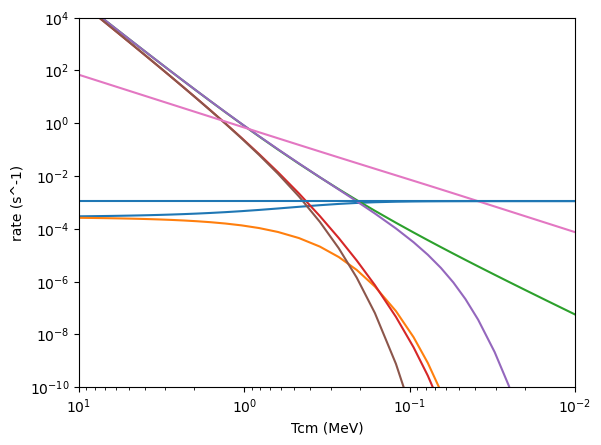

In [137]:
#Figure 1

plt.figure()
T = y[:,0]
N1 = np.zeros(len(1/a))
N2 = np.zeros(len(1/a))
N3 = np.zeros(len(1/a))
N4 = np.zeros(len(1/a))
N5 = np.zeros(len(1/a))
N6 = np.zeros(len(1/a))
N7 = np.zeros(len(1/a))

for i in range(len(T)):
    N1[i] = N(T[i],a[i])/(6.58e-22)
    N2[i] = N_antiep(T[i],a[i])/(6.58e-22)
    N3[i] = N_neutrinoen(T[i],a[i])/(6.58e-22)
    N4[i] = N_ep(T[i],a[i])/(6.58e-22)
    N5[i] = N_posn(T[i],a[i])/(6.58e-22)
    N6[i] = N_antip(T[i],a[i])/(6.58e-22)
    N7[i] = H(T[i],a[i])/(6.58e-22)
plt.loglog(1/a,N1)
plt.loglog(1/a,N2)
plt.loglog(1/a,N3)
plt.loglog(1/a,N4)
plt.loglog(1/a,N5)
plt.loglog(1/a,N6)
plt.loglog(1/a,N7)
plt.xlim(1e1,1e-2)
plt.ylim(1e-10,1e4)
plt.axhline(1/903)
plt.xlabel("Tcm (MeV)")
plt.ylabel("rate (s^-1)")




In [139]:
def NLaguerre(B):


    integrand=np.zeros(50)
    
    for j in range(len(integrand)):
        E=(x[j]+B)
        u=E-B
        integrand[j] = x[j]*np.exp(-x[j]**2)
    return np.sum(w*integrand*np.exp(x))
NLaguerre(0)



    


0.5000000145076594